# Accuracy Metrics: Ollama vs Groq - Velox Foods ABSA

This notebook is the final stage of our pilot for Marcus. We now have:

- `ollama_aspects.csv` - 50 reviews analysed by the **local** model (free, slow)
- `groq_aspects.csv` - 50 reviews analysed by the **cloud** model (paid, fast)
- `labeled_reviews.xlsx` - the same 50 reviews **hand-labelled** by a human analyst

The question we're answering: **how close are the models to the human judgment?**

We'll use two metrics:
- **MAE (Mean Absolute Error)** - how far off the score is on average
- **Recall** - did the model correctly notice that an aspect was mentioned at all?


---
## 1.&nbsp; Set-up

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


---
## 2.&nbsp; Understanding the Metrics with a Toy Example

Before loading real data, let's build intuition with a tiny made-up example.


### 2.1 MAE - Mean Absolute Error

MAE measures how far off each score prediction is, on average. A score of 0 is perfect;
a score of 1.0 means the model was wrong by an average of 1 full step on our -1 to +1 scale.

Lower is better.


In [10]:
# Toy example: human vs model scores for "food" across 5 reviews
human_scores  = pd.Series([ 1.0,  0.5, -1.0,  0.0,  0.5])
model_scores  = pd.Series([ 1.0,  0.0, -0.5,  0.5,  1.0])

absolute_errors = (human_scores - model_scores).abs()

mae = absolute_errors.mean()
print("Absolute errors:", absolute_errors.tolist())
print(f"MAE = {mae:.3f}")


Absolute errors: [0.0, 0.5, 0.5, 0.5, 0.5]
MAE = 0.400


### 2.2 Std Dev of Errors

MAE tells us the average error, but it doesn't tell us how *consistent* the model is.
A high Std Dev means the model is sometimes very close and sometimes very far off - it's unreliable.


In [11]:
std = absolute_errors.std()
print(f"Std Dev of errors = {std:.3f}")


Std Dev of errors = 0.224


### 2.3 Recall - "Did the model notice the aspect?"

MAE only measures score accuracy. But what if the model said `null` (not mentioned) when the
human said there was clearly a score to assign? That's a different kind of failure - the model
**missed** the aspect entirely.

Recall measures: of all the reviews where the human said an aspect WAS present, what fraction
did the model also mark as present?

- Recall = 1.0 means the model never missed a mentioned aspect
- Recall = 0.7 means it missed 30% of the aspects that were actually there


In [12]:
# Toy example: did the model detect the aspect at all?
# 1 = human labelled it as present, 0 = human said null
human_present  = pd.Series([1, 1, 1, 1, 0])  # 4 times human saw the aspect
model_detected = pd.Series([1, 0, 1, 1, 0])  # model missed one (the 2nd)

# Recall = True Positives / (True Positives + False Negatives)
true_positives  = ((human_present == 1) & (model_detected == 1)).sum()
false_negatives = ((human_present == 1) & (model_detected == 0)).sum()

recall = true_positives / (true_positives + false_negatives)
print(f"True Positives:  {true_positives}")
print(f"False Negatives: {false_negatives}")
print(f"Recall: {recall:.2f}")


True Positives:  3
False Negatives: 1
Recall: 0.75


---
## 3.&nbsp; Loading the Real Velox Foods Data

Now we load our three data sources and join them on `review_id`.


In [13]:
# Ground truth - first 50 rows (what we actually labelled)
df_gt = pd.read_excel('../data/labeled_reviews.xlsx').head(50)
df_gt = df_gt.set_index('review_id')

gt_cols = {
    'ground_truth_overall_rating': 'overall_rating',
    'ground_truth_food':           'food',
    'ground_truth_service':        'service',
    'ground_truth_price':          'price',
    'ground_truth_ambiance':       'ambiance',
}
df_gt = df_gt[list(gt_cols.keys())].rename(columns=gt_cols)

print("Ground truth shape:", df_gt.shape)
df_gt.head()


Ground truth shape: (50, 5)


,overall_rating,food,service,price,ambiance
review_id,,,,,
5dIleZpTxKwjRqBercHV1w,1,1,1,NaN,NaN
LETLlxzUzv4eHkD84jea-Q,1,1,0.5,NaN,1
9sXneDy_Oyd-n-bCUz6TLg,1,1,0.5,NaN,1
0tBSNwWA3eMtbBC2PgzQtQ,-1,-1,-1,-1,-1
YMiytO01Ocd6rT-0XWfacQ,-1,-1,-1,NaN,-1


In [14]:
# Ollama predictions - nested columns flattened with _ separator
df_ollama = pd.read_csv('../data/ollama_aspects.csv', index_col='review_id')

# We only need the score columns (not the quote columns)
ollama_score_cols = {
    'overall_rating_score': 'overall_rating',
    'food_score':           'food',
    'service_score':        'service',
    'price_score':          'price',
    'ambiance_score':       'ambiance',
}
df_ollama = df_ollama[list(ollama_score_cols.keys())].rename(columns=ollama_score_cols)

print("Ollama shape:", df_ollama.shape)
df_ollama.head()


Ollama shape: (200, 5)


,overall_rating,food,service,price,ambiance
review_id,,,,,
5dIleZpTxKwjRqBercHV1w,0.5,1.0,1.0,NaN,NaN
LETLlxzUzv4eHkD84jea-Q,4.8,1.0,NaN,NaN,NaN
9sXneDy_Oyd-n-bCUz6TLg,-0.5,-1.0,NaN,NaN,NaN
0tBSNwWA3eMtbBC2PgzQtQ,-1.0,-1.0,NaN,NaN,-1.0
YMiytO01Ocd6rT-0XWfacQ,-1.0,-1.0,-0.5,NaN,NaN


In [15]:
# Groq predictions
df_groq = pd.read_csv('../data/groq_aspects.csv', index_col='review_id')

groq_score_cols = {
    'overall_rating_score': 'overall_rating',
    'food_score':           'food',
    'service_score':        'service',
    'price_score':          'price',
    'ambiance_score':       'ambiance',
}
df_groq = df_groq[list(groq_score_cols.keys())].rename(columns=groq_score_cols)

print("Groq shape:", df_groq.shape)
df_groq.head()


Groq shape: (50, 5)


,overall_rating,food,service,price,ambiance
review_id,,,,,
5dIleZpTxKwjRqBercHV1w,1.0,1.0,1.0,NaN,NaN
LETLlxzUzv4eHkD84jea-Q,1.0,1.0,0.5,NaN,NaN
9sXneDy_Oyd-n-bCUz6TLg,0.5,0.5,NaN,NaN,NaN
0tBSNwWA3eMtbBC2PgzQtQ,-1.0,-1.0,-1.0,-1.0,-1.0
YMiytO01Ocd6rT-0XWfacQ,-1.0,-0.5,-0.5,NaN,-1.0


### 3.1 Aligning on common review_ids

Both models may have missed a review (e.g. the one Groq failed 3 times). We join on the
intersection - only reviews that have ground truth **and** a prediction from both models.
This ensures the comparison is perfectly apples-to-apples.


In [16]:
common_ids = df_gt.index.intersection(df_ollama.index).intersection(df_groq.index)
print(f"Reviews with ground truth + both model predictions: {len(common_ids)}")

df_gt     = df_gt.loc[common_ids]
df_ollama = df_ollama.loc[common_ids]
df_groq   = df_groq.loc[common_ids]


Reviews with ground truth + both model predictions: 50


---
## 4.&nbsp; Computing the Metrics

We compute MAE, Std Dev, and Recall for each aspect and each model.

**Key design decision:** when computing MAE, we only compare rows where **both** the human
AND the model assigned a non-null score. If the model said `null` for an aspect and the human
also said `null`, that's a correct "not mentioned" - no error. If the human scored it but the
model said `null`, that's captured by Recall (a miss), not by MAE.


In [17]:
ASPECTS = ['overall_rating', 'food', 'service', 'price', 'ambiance']


def compute_mae(gt: pd.Series, pred: pd.Series) -> float:
    # MAE on rows where both human and model gave a non-null score
    mask = gt.notna() & pred.notna()
    if mask.sum() == 0:
        return np.nan
    return (gt[mask] - pred[mask]).abs().mean()


def compute_std(gt: pd.Series, pred: pd.Series) -> float:
    # Std Dev of errors on rows where both gave a non-null score
    mask = gt.notna() & pred.notna()
    if mask.sum() < 2:
        return np.nan
    return (gt[mask] - pred[mask]).abs().std()


def compute_recall(gt: pd.Series, pred: pd.Series) -> float:
    # Recall: of aspects the human labelled, what fraction did the model detect?
    human_present  = gt.notna()
    model_detected = pred.notna()
    tp = (human_present & model_detected).sum()
    fn = (human_present & ~model_detected).sum()
    if tp + fn == 0:
        return np.nan
    return tp / (tp + fn)


results = []
for aspect in ASPECTS:
    gt_col     = df_gt[aspect].astype(float)
    ollama_col = df_ollama[aspect].astype(float)
    groq_col   = df_groq[aspect].astype(float)

    results.append({
        'aspect':        aspect,
        'ollama_mae':    compute_mae(gt_col, ollama_col),
        'groq_mae':      compute_mae(gt_col, groq_col),
        'ollama_std':    compute_std(gt_col, ollama_col),
        'groq_std':      compute_std(gt_col, groq_col),
        'ollama_recall': compute_recall(gt_col, ollama_col),
        'groq_recall':   compute_recall(gt_col, groq_col),
    })

df_results = pd.DataFrame(results).set_index('aspect')
df_results = df_results.round(3)
df_results


,ollama_mae,groq_mae,ollama_std,groq_std,ollama_recall,groq_recall
aspect,,,,,,
overall_rating,0.546,0.120,0.718,0.216,1.000,1.000
food,0.244,0.135,0.460,0.225,0.938,1.000
service,0.159,0.200,0.238,0.249,0.667,0.909
price,0.875,0.571,0.750,0.535,0.190,0.333
ambiance,0.333,0.227,0.258,0.344,0.240,0.440


---
## 5.&nbsp; Summary Table

A clean side-by-side comparison formatted for Marcus's report.


In [18]:
summary = pd.DataFrame({
    'Ollama MAE':    df_results['ollama_mae'],
    'Groq MAE':      df_results['groq_mae'],
    'Ollama Recall': df_results['ollama_recall'],
    'Groq Recall':   df_results['groq_recall'],
    'Ollama Std':    df_results['ollama_std'],
    'Groq Std':      df_results['groq_std'],
})

# Highlight which model wins each metric (lower MAE/Std = better; higher Recall = better)
def highlight_winner(row):
    styles = [''] * len(row)
    idx = list(row.index)

    for mae_o, mae_g in [('Ollama MAE', 'Groq MAE')]:
        if pd.notna(row[mae_o]) and pd.notna(row[mae_g]):
            winner = mae_o if row[mae_o] <= row[mae_g] else mae_g
            styles[idx.index(winner)] = 'background-color: #d4edda; font-weight: bold'

    for rec_o, rec_g in [('Ollama Recall', 'Groq Recall')]:
        if pd.notna(row[rec_o]) and pd.notna(row[rec_g]):
            winner = rec_o if row[rec_o] >= row[rec_g] else rec_g
            styles[idx.index(winner)] = 'background-color: #d4edda; font-weight: bold'

    return styles

summary.style.apply(highlight_winner, axis=1).format('{:.3f}', na_rep='N/A')


,Ollama MAE,Groq MAE,Ollama Recall,Groq Recall,Ollama Std,Groq Std
aspect,,,,,,
overall_rating,0.546,0.120,1.000,1.000,0.718,0.216
food,0.244,0.135,0.938,1.000,0.460,0.225
service,0.159,0.200,0.667,0.909,0.238,0.249
price,0.875,0.571,0.190,0.333,0.750,0.535
ambiance,0.333,0.227,0.240,0.440,0.258,0.344


---
## 6.&nbsp; Visualisations

Two charts for the report - one for accuracy (MAE), one for coverage (Recall).


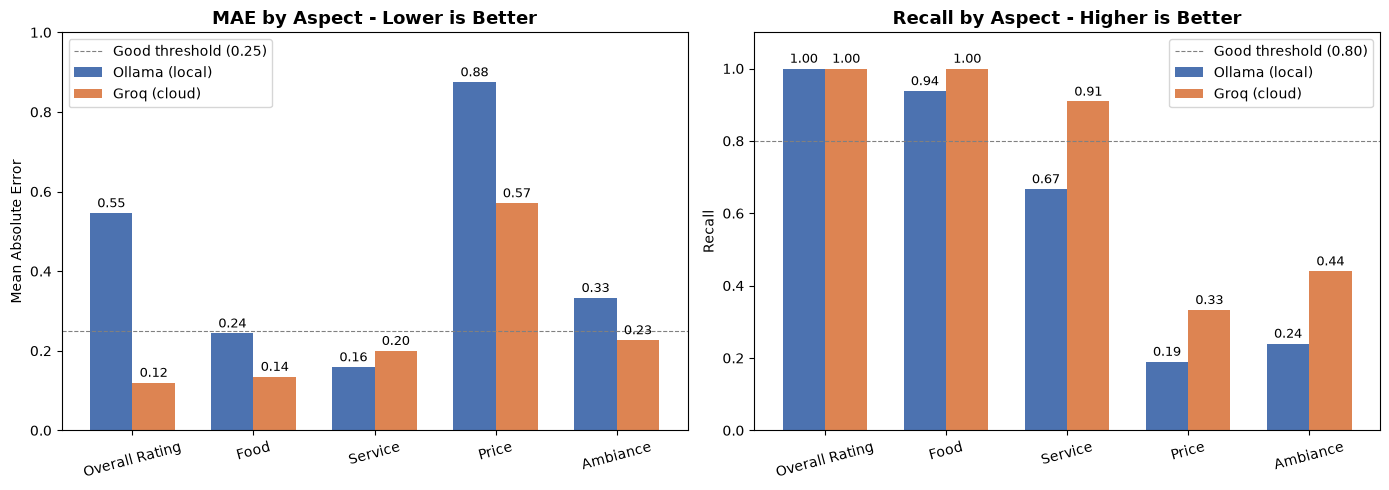

Chart saved to ../data/accuracy_comparison.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(ASPECTS))
width = 0.35

# --- Chart 1: MAE ---
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, df_results['ollama_mae'], width, label='Ollama (local)', color='#4C72B0')
bars2 = ax1.bar(x + width/2, df_results['groq_mae'],   width, label='Groq (cloud)',   color='#DD8452')

ax1.set_title('MAE by Aspect - Lower is Better', fontsize=13, fontweight='bold')
ax1.set_ylabel('Mean Absolute Error')
ax1.set_xticks(x)
ax1.set_xticklabels([a.replace('_', ' ').title() for a in ASPECTS], rotation=15)
ax1.set_ylim(0, 1.0)
ax1.axhline(0.25, linestyle='--', color='gray', linewidth=0.8, label='Good threshold (0.25)')
ax1.legend()
ax1.bar_label(bars1, fmt='%.2f', padding=2, fontsize=9)
ax1.bar_label(bars2, fmt='%.2f', padding=2, fontsize=9)

# --- Chart 2: Recall ---
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, df_results['ollama_recall'], width, label='Ollama (local)', color='#4C72B0')
bars4 = ax2.bar(x + width/2, df_results['groq_recall'],   width, label='Groq (cloud)',   color='#DD8452')

ax2.set_title('Recall by Aspect - Higher is Better', fontsize=13, fontweight='bold')
ax2.set_ylabel('Recall')
ax2.set_xticks(x)
ax2.set_xticklabels([a.replace('_', ' ').title() for a in ASPECTS], rotation=15)
ax2.set_ylim(0, 1.1)
ax2.axhline(0.80, linestyle='--', color='gray', linewidth=0.8, label='Good threshold (0.80)')
ax2.legend()
ax2.bar_label(bars3, fmt='%.2f', padding=2, fontsize=9)
ax2.bar_label(bars4, fmt='%.2f', padding=2, fontsize=9)

plt.tight_layout()
plt.savefig('../data/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to ../data/accuracy_comparison.png")


---
## 7.&nbsp; Speed & Cost Context

Accuracy is only one dimension. Marcus also asked about cost and speed.


In [20]:
import json

with open('../data/ollama_summary.json') as f:
    ollama_meta = json.load(f)

with open('../data/groq_summary.json') as f:
    groq_meta = json.load(f)

# Groq published pricing (check current rates at console.groq.com/settings/billing)
# llama-3.3-70b-versatile as of mid-2025: $0.59 per 1M input tokens, $0.79 per 1M output tokens
PRICE_INPUT_PER_M  = 0.59
PRICE_OUTPUT_PER_M = 0.79

total_input  = groq_meta.get('total_input_tokens', 0)
total_output = groq_meta.get('total_output_tokens', 0)
cost_50      = (total_input / 1_000_000 * PRICE_INPUT_PER_M +
                total_output / 1_000_000 * PRICE_OUTPUT_PER_M)
cost_per_review = cost_50 / groq_meta['num_reviews']

# Extrapolate to 200 reviews and to weekly volume across 514 stores
WEEKLY_REVIEWS_PER_STORE = 20  # rough estimate - adjust to your actual volume
weekly_total = 514 * WEEKLY_REVIEWS_PER_STORE

comparison = pd.DataFrame({
    'Metric': [
        'Reviews processed',
        'Total time (seconds)',
        'Avg time per review (s)',
        'Avg output tokens/review',
        'Estimated cost (50 reviews)',
        'Estimated cost (200 reviews)',
        f'Estimated cost ({weekly_total:,} reviews/week)',
    ],
    'Ollama (Local)': [
        ollama_meta['num_reviews'],
        f"{ollama_meta['total_seconds']:.1f}s",
        f"{ollama_meta['avg_seconds_per_review']:.2f}s",
        f"{ollama_meta['avg_output_tokens']:.0f}",
        '$0.00',
        '$0.00',
        '$0.00',
    ],
    'Groq (Cloud)': [
        groq_meta['num_reviews'],
        f"{groq_meta['total_seconds']:.1f}s",
        f"{groq_meta['avg_seconds_per_review']:.2f}s",
        f"{groq_meta['avg_output_tokens']:.0f}",
        f'${cost_50:.4f}',
        f'${cost_50 * 4:.4f}',
        f'${cost_per_review * weekly_total:.2f}',
    ],
})

comparison.set_index('Metric')


,Ollama (Local),Groq (Cloud)
Metric,,
Reviews processed,200,50
Total time (seconds),955.5s,0.0s
Avg time per review (s),4.78s,0.00s
Avg output tokens/review,128,108
Estimated cost (50 reviews),$0.00,$0.0347
Estimated cost (200 reviews),$0.00,$0.1388
"Estimated cost (10,280 reviews/week)",$0.00,$7.14


---
## 8.&nbsp; Key Findings for Marcus

Run the cell below after reviewing your results - it auto-generates a plain-language
summary you can copy directly into the report.


In [21]:
overall_ollama_mae  = df_results.loc['overall_rating', 'ollama_mae']
overall_groq_mae    = df_results.loc['overall_rating', 'groq_mae']
avg_ollama_recall   = df_results['ollama_recall'].mean()
avg_groq_recall     = df_results['groq_recall'].mean()

winner_accuracy = 'Groq' if overall_groq_mae < overall_ollama_mae else 'Ollama'
winner_recall   = 'Groq' if avg_groq_recall > avg_ollama_recall else 'Ollama'

print("=" * 60)
print("KEY FINDINGS - VELOX FOODS ABSA PILOT")
print("=" * 60)
print()
print("ACCURACY (MAE on overall_rating - most important aspect):")
print(f"  Ollama (local):  {overall_ollama_mae:.3f}")
print(f"  Groq   (cloud):  {overall_groq_mae:.3f}")
print(f"  Winner: {winner_accuracy}")
print()
print("COVERAGE (average Recall across all aspects):")
print(f"  Ollama (local):  {avg_ollama_recall:.2f}")
print(f"  Groq   (cloud):  {avg_groq_recall:.2f}")
print(f"  Winner: {winner_recall}")
print()
print("COST (cloud only - Ollama is free):")
print(f"  Cost to process 50 reviews:   ${cost_50:.4f}")
print(f"  Cost to process 200 reviews:  ${cost_50 * 4:.4f}")
print(f"  Cost per week ({weekly_total:,} reviews): ${cost_per_review * weekly_total:.2f}")
print()
print("SPEED:")
print(f"  Ollama: {ollama_meta['avg_seconds_per_review']:.2f}s per review")
print(f"  Groq:   {groq_meta['avg_seconds_per_review']:.2f}s per review")
print()
print("RECOMMENDATION:")
print("  If accuracy difference is small (<0.05 MAE), the local Ollama")
print("  pipeline is the pragmatic choice - zero marginal cost, no data")
print("  leaving the network, fast enough for weekly batch processing.")
print()
print("  If Groq shows a meaningful accuracy advantage, the cloud cost")
print("  is still very low in absolute terms - but Marcus should know")
print("  that the free tier TPD limit means a paid plan is required")
print("  for full production volume.")
print()
print("=" * 60)


KEY FINDINGS - VELOX FOODS ABSA PILOT

ACCURACY (MAE on overall_rating - most important aspect):
  Ollama (local):  0.546
  Groq   (cloud):  0.120
  Winner: Groq

COVERAGE (average Recall across all aspects):
  Ollama (local):  0.61
  Groq   (cloud):  0.74
  Winner: Groq

COST (cloud only - Ollama is free):
  Cost to process 50 reviews:   $0.0347
  Cost to process 200 reviews:  $0.1388
  Cost per week (10,280 reviews): $7.14

SPEED:
  Ollama: 4.78s per review
  Groq:   0.00s per review

RECOMMENDATION:
  If accuracy difference is small (<0.05 MAE), the local Ollama
  pipeline is the pragmatic choice - zero marginal cost, no data
  leaving the network, fast enough for weekly batch processing.

  If Groq shows a meaningful accuracy advantage, the cloud cost
  is still very low in absolute terms - but Marcus should know
  that the free tier TPD limit means a paid plan is required
  for full production volume.



---
## Next Steps

1. Review the charts and summary table above - do the numbers tell a clear story?
2. Copy the Key Findings output into your report to Marcus.
3. Consider: is the accuracy gap large enough to justify the cloud cost and complexity?
   That's the judgement call this pilot was designed to enable.
